
Loading yearly graphs
Loaded 2013_2014 1/13 (  7.7%) | elapsed 0s, ETA 0s
Loaded 2014_2015 2/13 ( 15.4%) | elapsed 0s, ETA 0s
Loaded 2015_2016 3/13 ( 23.1%) | elapsed 0s, ETA 0s
Loaded 2016_2017 4/13 ( 30.8%) | elapsed 0s, ETA 0s
Loaded 2017_2018 5/13 ( 38.5%) | elapsed 0s, ETA 0s
Loaded 2018_2019 6/13 ( 46.2%) | elapsed 0s, ETA 0s
Loaded 2019_2020 7/13 ( 53.8%) | elapsed 0s, ETA 0s
Loaded 2020_2021 8/13 ( 61.5%) | elapsed 0s, ETA 0s
Loaded 2021_2022 9/13 ( 69.2%) | elapsed 0s, ETA 0s
Loaded 2022_2023 10/13 ( 76.9%) | elapsed 0s, ETA 0s
Loaded 2024_2025 12/13 ( 92.3%) | elapsed 0s, ETA 0s
Loaded 2025_2026 13/13 (100.0%) | elapsed 0s, ETA 0s

Precomputing portraits
Portrait 2013_2014 1/12 (  8.3%) | elapsed 33s, ETA 6m 10s
Portrait 2014_2015 2/12 ( 16.7%) | elapsed 1m 4s, ETA 5m 23s
Portrait 2015_2016 3/12 ( 25.0%) | elapsed 1m 33s, ETA 4m 40s
Portrait 2016_2017 4/12 ( 33.3%) | elapsed 2m 2s, ETA 4m 4s
Portrait 2017_2018 5/12 ( 41.7%) | elapsed 2m 37s, ETA 3m 41s
Portrait 2018_2019 6/1

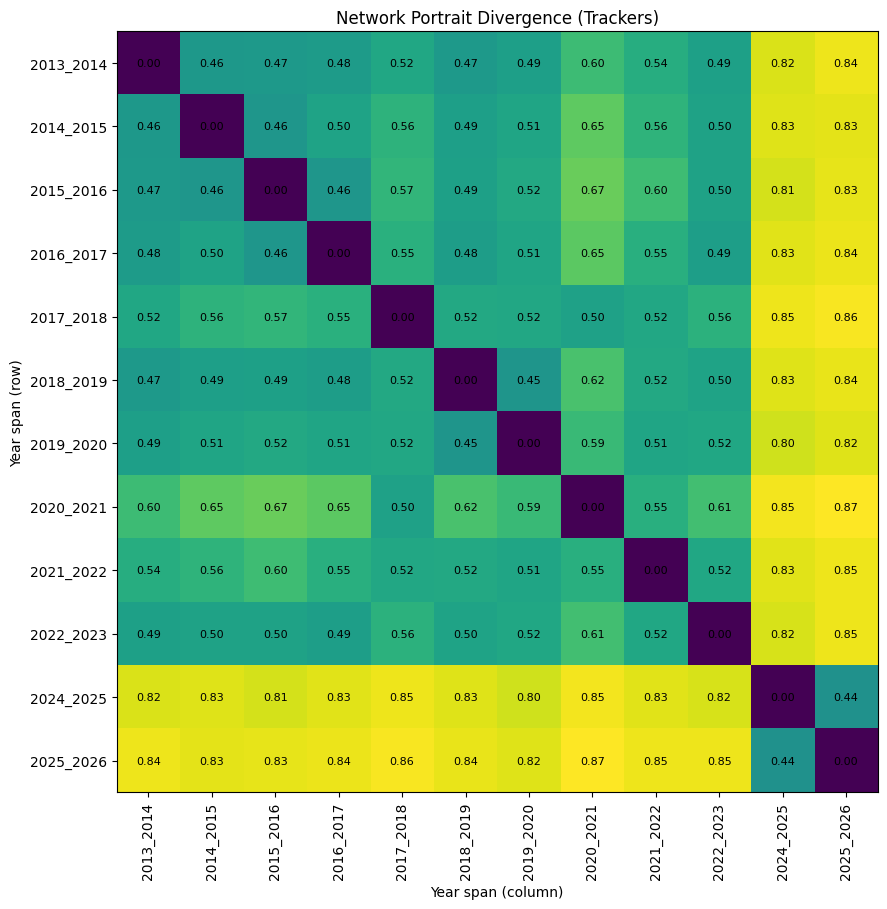

Saved heatmap to trackers_npd_heatmap.png

====
Done
====
All stages completed successfully.


In [1]:


import os
import sys
import csv
import time
import math
import pickle
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.stats import entropy


SPANS = [
    "2013_2014","2014_2015","2015_2016","2016_2017","2017_2018","2018_2019",
    "2019_2020","2020_2021","2021_2022","2022_2023","2023_2024","2024_2025","2025_2026"
]

CSV_OUT = "trackers_npd_matrix.csv"
PNG_OUT = "trackers_npd_heatmap.png"

def fmt_hms(seconds: float) -> str:
    seconds = max(0, int(seconds))
    h = seconds // 3600
    m = (seconds % 3600) // 60
    s = seconds % 60
    if h > 0:
        return f"{h}h {m}m {s}s"
    if m > 0:
        return f"{m}m {s}s"
    return f"{s}s"

def print_stage(title: str):
    print("\n" + "="*len(title))
    print(title)
    print("="*len(title))
    sys.stdout.flush()

def print_progress(done: int, total: int, start_time: float, prefix: str = ""):
    done = min(done, total)
    pct = (done / total) * 100 if total else 100.0
    elapsed = time.time() - start_time
    rate = done / elapsed if elapsed > 0 else 0.0
    remaining = (total - done) / rate if rate > 0 else float("inf")
    msg = f"{prefix} {done}/{total} ({pct:5.1f}%) | elapsed {fmt_hms(elapsed)}, ETA {fmt_hms(remaining)}"
    print(msg)
    sys.stdout.flush()


def _graph_diameter_max_component(G: nx.Graph) -> int:
    """Max diameter over connected components (handles disconnected graphs)."""
    if G.number_of_nodes() <= 1:
        return 0
    if nx.is_connected(G):
        return nx.diameter(G)
    dia = 0
    for comp in nx.connected_components(G):
        sub = G.subgraph(comp)
        if sub.number_of_nodes() > 1:
            dia = max(dia, nx.diameter(sub))
    return dia

def portrait_py(G: nx.Graph) -> np.ndarray:
    """
    Return B where B[i,j] = #starting nodes that see exactly j nodes
    at shell (distance) i from them.
    Optimized to allocate rows up to true diameter (max over components).
    """
    N = G.number_of_nodes()
    if N == 0:
        return np.zeros((1, 1), dtype=float)

    dia = _graph_diameter_max_component(G)
    B = np.zeros((dia + 1, N), dtype=float)

    max_path = 0
    adj = G.adj
    for s in G.nodes():
        nodes_visited = {s: 0}
        frontier = [s]
        d = 1
        while frontier:
            nxt = []
            extend = nxt.extend
            for u in frontier:
                # unvisited neighbors
                l = [v for v in adj[u] if v not in nodes_visited]
                extend(l)
                for v in l:
                    nodes_visited[v] = d
            frontier = nxt
            d += 1

        dists = list(nodes_visited.values())
        if dists:
            shell_max = max(dists)
            max_path = max(max_path, shell_max)

        # count how many are at each shell
        dist_counts = {}
        for dd in dists:
            dist_counts[dd] = dist_counts.get(dd, 0) + 1

        # update B: for shell i, if we see 'count' nodes, add 1 at (i, count)
        for shell, count in dist_counts.items():
            if shell <= dia and count < N:
                B[shell, count] += 1

    return B[:max_path + 1, :]

def pad_portraits_to_same_size(B1: np.ndarray, B2: np.ndarray):
    """Pad/trim two portraits so they match shape and occupied columns."""
    ns, ms = B1.shape
    nl, ml = B2.shape

    def last_occupied_col(B):
        nz = np.nonzero(B)
        if nz[1].size == 0:
            return 0
        return int(np.max(nz[1]))

    lastcol = max(last_occupied_col(B1), last_occupied_col(B2))
    B1 = B1[:, :lastcol + 1]
    B2 = B2[:, :lastcol + 1]

    R = max(B1.shape[0], B2.shape[0])
    C = lastcol + 1
    BB1 = np.zeros((R, C))
    BB2 = np.zeros((R, C))
    BB1[:B1.shape[0], :B1.shape[1]] = B1
    BB2[:B2.shape[0], :B2.shape[1]] = B2
    return BB1, BB2

def portrait_divergence_from_portraits(BG: np.ndarray, BH: np.ndarray) -> float:
    BG, BH = pad_portraits_to_same_size(BG, BH)
    L, K = BG.shape
    if L == 0 or K == 0:
        return 0.0

    # column weights j
    V = np.tile(np.arange(K), (L, 1)).astype(float)

    XG = BG * V
    XH = BH * V
    sumG = XG.sum()
    sumH = XH.sum()

    # handle degenerate cases safely
    if sumG == 0 and sumH == 0:
        return 0.0
    P = (XG / (sumG if sumG > 0 else 1)).ravel()
    Q = (XH / (sumH if sumH > 0 else 1)).ravel()

    M = 0.5 * (P + Q)
    KLDpm = entropy(P, M, base=2)
    KLDqm = entropy(Q, M, base=2)
    return 0.5 * (KLDpm + KLDqm)

# --------------
# Load all graphs
# --------------
def load_graph(span: str) -> nx.Graph:
    fname = f"graph_{span}.gpickle"
    if not os.path.exists(fname):
        raise FileNotFoundError(fname)
    # Try networkx reader first; fall back to raw pickle
    try:
        return nx.read_gpickle(fname)
    except Exception:
        with open(fname, "rb") as f:
            return pickle.load(f)

def main():
    # 1) Load graphs
    print_stage("Loading yearly graphs")
    graphs = {}
    missing = []
    t0 = time.time()
    for i, span in enumerate(SPANS, 1):
        try:
            G = load_graph(span)
            graphs[span] = G
            print_progress(i, len(SPANS), t0, prefix=f"Loaded {span}")
        except FileNotFoundError:
            missing.append(span)
            print(f"WARNING: missing file for {span} (skipping).")
    labels = list(graphs.keys())
    n = len(labels)
    if n == 0:
        print("ERROR: No graphs loaded. Place the .gpickle files next to this script and re-run.")
        return

    # 2) Precompute portraits (huge speedup for pairwise NPD)
    print_stage("Precomputing portraits")
    portraits = {}
    t1 = time.time()
    for i, span in enumerate(labels, 1):
        portraits[span] = portrait_py(graphs[span])
        print_progress(i, n, t1, prefix=f"Portrait {span}")

    # 3) Compute pairwise NPD matrix (use symmetry to halve work)
    print_stage("Computing pairwise NPD")
    npd = np.zeros((n, n), dtype=float)
    t2 = time.time()
    total_pairs = n * (n + 1) // 2  # diagonal + upper triangle
    done_pairs = 0
    for i in range(n):
        Bi = portraits[labels[i]]
        for j in range(i, n):
            Bj = portraits[labels[j]]
            d = portrait_divergence_from_portraits(Bi, Bj)
            npd[i, j] = d
            npd[j, i] = d
            done_pairs += 1
            # Print status every some pairs (or at end of each row)
            if done_pairs == total_pairs or done_pairs % max(1, total_pairs // 20) == 0:
                print_progress(done_pairs, total_pairs, t2, prefix="NPD pairs")

    # 4) Save CSV
    print_stage("Saving CSV")
    with open(CSV_OUT, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([""] + labels)
        for i in range(n):
            w.writerow([labels[i]] + [f"{npd[i, j]:.6f}" for j in range(n)])
    print(f"Saved NPD matrix to {CSV_OUT}")

    # 5) Plot heatmap
    print_stage("Plotting heatmap")
    fig, ax = plt.subplots(figsize=(0.6*n + 2, 0.6*n + 2))
    im = ax.imshow(npd, interpolation="nearest")  # default colormap
    ax.set_xticks(range(n))
    ax.set_yticks(range(n))
    ax.set_xticklabels(labels, rotation=90)
    ax.set_yticklabels(labels)
    ax.set_xlabel("Year span (column)")
    ax.set_ylabel("Year span (row)")
    ax.set_title("Network Portrait Divergence (Trackers)")

    # annotate cells (comment out for very large n)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{npd[i, j]:.2f}", ha="center", va="center", fontsize=8)

    fig.tight_layout()
    plt.savefig(PNG_OUT, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved heatmap to {PNG_OUT}")

    print_stage("Done")
    print("All stages completed successfully.")

if __name__ == "__main__":
    main()


In [2]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy
import pickle
def cal_dia(G: nx.Graph) -> int:
    """Max diameter over connected components (handles disconnected graphs)."""
    if G.number_of_nodes() <= 1:
        return 0
    if nx.is_connected(G):
        return nx.diameter(G)
    dia = 0
    for comp in nx.connected_components(G):
        sub = G.subgraph(comp)
        if sub.number_of_nodes() > 1:
            dia = max(dia, nx.diameter(sub))
    return dia

def portrait_py(graph):
    dia = cal_dia(graph)  # placeholder diameter
    N = graph.number_of_nodes()
    B = np.zeros((dia+1, N))
    max_path = 1
    adj = graph.adj
    for starting_node in graph.nodes():
        nodes_visited = {starting_node: 0}
        search_queue = [starting_node]
        d = 1
        while search_queue:
            next_depth = []
            extend = next_depth.extend
            for n in search_queue:
                l = [i for i in adj[n] if i not in nodes_visited]
                extend(l)
                for j in l:
                    nodes_visited[j] = d
            search_queue = next_depth
            d += 1
        node_distances = nodes_visited.values()
        max_node_distances = max(node_distances)
        if max_node_distances > max_path:
            max_path = max_node_distances
        dict_distribution = dict.fromkeys(node_distances, 0)
        for d in node_distances:
            dict_distribution[d] += 1
        for shell, count in dict_distribution.items():
            B[shell][count] += 1
        max_shell = dia
        while max_shell > max_node_distances:
            B[max_shell][0] += 1
            max_shell -= 1
    return B[:max_path+1, :]

portrait = portrait_py

def pad_portraits_to_same_size(B1, B2):
    ns, ms = B1.shape
    nl, ml = B2.shape
    lastcol1 = max(np.nonzero(B1)[1])
    lastcol2 = max(np.nonzero(B2)[1])
    lastcol = max(lastcol1, lastcol2)
    B1 = B1[:, :lastcol+1]
    B2 = B2[:, :lastcol+1]
    BigB1 = np.zeros((max(ns, nl), lastcol+1))
    BigB2 = np.zeros((max(ns, nl), lastcol+1))
    BigB1[:B1.shape[0], :B1.shape[1]] = B1
    BigB2[:B2.shape[0], :B2.shape[1]] = B2
    return BigB1, BigB2

def _graph_or_portrait(X):
    if isinstance(X, (nx.Graph, nx.DiGraph)):
        return portrait(X)
    return X

def portrait_divergence(G, H):
    BG = _graph_or_portrait(G)
    BH = _graph_or_portrait(H)
    print("BG",BG)
    print("BH",BH)
    BG, BH = pad_portraits_to_same_size(BG, BH)
    L, K = BG.shape
    V = np.tile(np.arange(K), (L, 1))
    XG = BG*V / (BG*V).sum()
    XH = BH*V / (BH*V).sum()
    P = XG.ravel()
    Q = XH.ravel()
    M = 0.5*(P+Q)
    KLDpm = entropy(P, M, base=2)
    KLDqm = entropy(Q, M, base=2)
    JSDpq = 0.5*(KLDpm + KLDqm)
    return JSDpq

# === Example run ===


result=dict
for start_year in range(2013,1):
  end_year=start_year+1
  with open(f"graph_{start_year}_{end_year}.gpickle", "rb") as f:
    G = pickle.load(f)
  for s in range(end_year):
    e=s+1
    with open(f"G_trackers_{s}_{e}.gpickle","rb") as f:
      H=pickle.load(f)
      D = portrait_divergence(G, H)

# Graph 1: path on 4 nodes

with open("G_trackers_2014_2015.gpickle", "rb") as f:
    G = pickle.load(f)

# Graph 2: star on 4 nodes (center+3 leaves)
with open("G_trackers_2023_2024.gpickle", "rb") as f:
    H = pickle.load(f)

# Compute portrait divergence
D = portrait_divergence(G, H)

print("Portrait divergence between Path(4) and Star(4) =", D)


FileNotFoundError: [Errno 2] No such file or directory: 'G_trackers_2014_2015.gpickle'

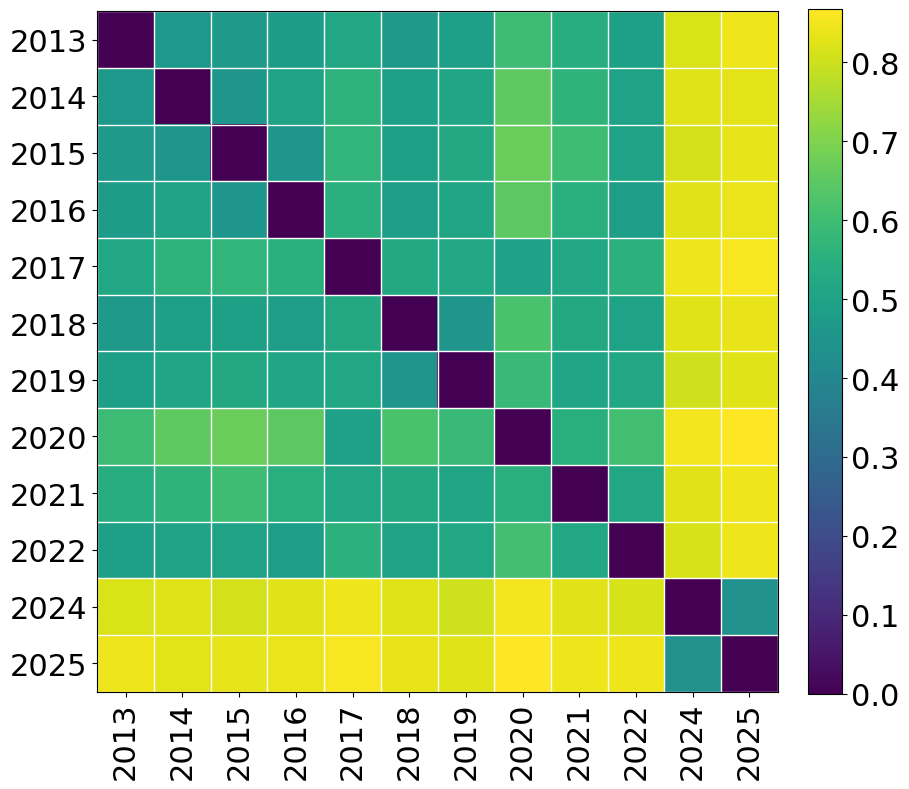

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "trackers_npd_matrix.csv"
out_png  = "trackers_npd_heatmap.png"

df = pd.read_csv(csv_path, index_col=0)
n = len(df)


df.index = [str(x).split("_")[0] for x in df.index]
df.columns = [str(x).split("_")[0] for x in df.columns]

fig, ax = plt.subplots(figsize=(0.6 * n + 2, 0.6 * n + 2))
im = ax.imshow(df.values, interpolation="nearest")


ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(df.columns, rotation=90, fontsize=22)
ax.set_yticklabels(df.index, fontsize=22)

# Add colorbar with fontsize 17
cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=22)

# White borders between cells
ax.set_xticks(np.arange(-0.5, n, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n, 1), minor=True)
ax.grid(which='minor', color='white', linestyle='-', linewidth=1)
ax.tick_params(which='minor', bottom=False, left=False)

fig.tight_layout()
plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.show()
